# 02 - IEMOCAP Feature Extraction: Emotion2Vec + Full Acoustic + Transcript-Ready Data

Notebook này là bước trích xuất đặc trưng sạch cho các mô hình phía sau. Không augmentation, không train model.

Mục tiêu chính:

1. Đọc metadata/split từ notebook 01.
2. Resolve audio từ IEMOCAP full release.
3. Chuẩn hóa audio ở mức preprocessing: mono, resample 16 kHz, normalize amplitude nếu cần, padding/truncation cố định để feature có shape ổn định.
4. Trích full acoustic features cho nhánh 06D/acoustic:
   - `X_temporal`: frame-level sequence cho Conv1D/temporal branch.
   - `X_spectral`: log-Mel/delta/delta-delta cho Conv2D/Spectral branch.
   - `X_stats`: utterance-level statistical functionals.
5. Trích hoặc chuẩn bị `X_e2v` cho nhánh emotion2vec.
6. Xuất transcript-ready tables cho nhánh pretrained transcript/text model.
7. Tạo report, figures, bảng thống kê và file cache dùng trực tiếp cho notebook 03B/04.

Output quan trọng nhất là:

```text
output/features/iemocap_full_06d_multibranch_cache.npz
```

Cache này được thiết kế để notebook 03B đọc trực tiếp.


## Feature Contract Cho Các Notebook Sau

| Bước sau | Cần từ notebook 02 | File/cột liên quan |
|---|---|---|
| 03A raw-audio pretrained backbone | Metadata/split + `wav_path` để load raw waveform | `metadata/*.csv`, `splits/*.csv` |
| 03B full acoustic co-attention | `X_temporal`, `X_spectral`, `X_stats`, `X_e2v`, labels, ids | `features/iemocap_full_06d_multibranch_cache.npz` |
| Transcript pretrained model | `utterance_id`, `transcript`, labels, fold/split | `text/text_ready_metadata.csv`, `text/text_folds_long.csv`, `text/text_ready.jsonl` |
| 04 fusion | id thống nhất `train_sample_id`, `utterance_id`, fold/split, predictions/embeddings từ 03A/03B | cache + split CSV |

Lưu ý: `X_e2v` là optional nếu môi trường chưa cài FunASR/ModelScope. Khi chưa trích emotion2vec, notebook vẫn tạo cache với vector zero để pipeline không vỡ, nhưng trong báo cáo phải ghi rõ `emotion2vec_status`.


## Feature Groups

### `X_temporal`

Frame-level sequence, shape:

```text
(N, C_temporal, T)
```

Bao gồm:

- MFCC, delta MFCC, delta-delta MFCC.
- RMS energy.
- Zero-crossing rate.
- Spectral centroid, bandwidth, rolloff, flatness.
- Spectral contrast.
- Pitch/F0 bằng `librosa.yin`.
- Voiced flag.

Nhánh sử dụng: temporal Conv1D/TIM-Net-style branch trong 03B.

### `X_spectral`

Log-Mel image-like tensor, shape:

```text
(N, 3, n_mels, T)
```

Ba channel:

```text
log-Mel, delta log-Mel, delta-delta log-Mel
```

Nhánh sử dụng: Spectral CNN/ResNet branch trong 03B.

### `X_stats`

Utterance-level statistical functionals từ các feature frame-level:

```text
mean, std, min, max, median, p10, p90, iqr
```

Nhánh sử dụng: MLP stats branch, report/interpretability, ablation.

### `X_e2v`

Embedding pretrained emotion representation. Nếu bật:

```text
EXTRACT_EMOTION2VEC=1
```

Notebook sẽ thử dùng FunASR:

```text
iic/emotion2vec_base
```


## Minh Họa Trong Notebook Này

Notebook tạo nhiều bảng và hình:

- Một sample mỗi emotion: waveform, log-Mel, MFCC, F0.
- Cùng một speaker với nhiều emotion khác nhau, nếu dataset có đủ.
- Nếu có transcript trùng ở nhiều emotion, notebook sẽ cố tìm và minh họa "cùng/sát câu nói nhưng khác emotion"; nếu không có, dùng same-speaker multi-emotion thay thế.
- Heatmap feature means theo emotion.
- PCA từ `X_stats`.
- Correlation giữa acoustic stats và VAD.
- Duration/truncation risk.

Mục tiêu là phần feature extraction nhìn như một bước nghiên cứu thật sự, không chỉ là code tạo file.


In [1]:
import os
import re
import sys
import json
import time
import math
import shutil
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display, Markdown

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except Exception:
    plt = None
    sns = None

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != "Speech Project":
    for parent in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if parent.name == "Speech Project":
            PROJECT_ROOT = parent
            break

NOTEBOOK_DIR = Path(r"D:\UTE\Speech Programming\Speech Project\06_w2v_based_models\02_IEMOCAP Feature Extraction Emotion2Vec Acoustic")
if not NOTEBOOK_DIR.exists():
    NOTEBOOK_DIR = PROJECT_ROOT / "06_w2v_based_models" / "02_IEMOCAP Feature Extraction Emotion2Vec Acoustic"

OUTPUT_DIR = NOTEBOOK_DIR / "output"
FEATURE_DIR = OUTPUT_DIR / "features"
METADATA_DIR = OUTPUT_DIR / "metadata"
SPLIT_DIR = OUTPUT_DIR / "splits"
REPORT_DIR = OUTPUT_DIR / "feature_reports"
FIGURE_DIR = OUTPUT_DIR / "feature_figures"
TEXT_DIR = OUTPUT_DIR / "text"
CENTRAL_DATA_DIR = PROJECT_ROOT / "06_w2v_based_models" / "data"

RESET_OUTPUT = os.getenv("RESET_OUTPUT", "1") == "1"
if RESET_OUTPUT and OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
if RESET_OUTPUT:
    for stale_archive in [OUTPUT_DIR.with_suffix(".zip"), OUTPUT_DIR.with_suffix(".rar")]:
        if stale_archive.exists():
            stale_archive.unlink()

for path in [FEATURE_DIR, METADATA_DIR, SPLIT_DIR, REPORT_DIR, FIGURE_DIR, TEXT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_ROOT: /kaggle/working
NOTEBOOK_DIR: /kaggle/working/06_w2v_based_models/02_IEMOCAP Feature Extraction Emotion2Vec Acoustic
OUTPUT_DIR: /kaggle/working/06_w2v_based_models/02_IEMOCAP Feature Extraction Emotion2Vec Acoustic/output


## Dependency Setup

Notebook cần:

- `soundfile`: đọc wav.
- `librosa`: trích acoustic features.
- `scikit-learn`: PCA/standardization cho visualize.
- `funasr`, `modelscope`: chỉ cần nếu trích emotion2vec trực tiếp.

Trên Kaggle, nếu thiếu package, có thể bật Internet và set:

```text
INSTALL_DEPS=1
INSTALL_EMOTION2VEC_DEPS=1
EXTRACT_EMOTION2VEC=1
```


In [2]:
INSTALL_DEPS = os.getenv("INSTALL_DEPS", "0") == "1"
if INSTALL_DEPS:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "soundfile", "librosa", "scikit-learn"])

try:
    import soundfile as sf
    import librosa
    import librosa.display
except Exception as exc:
    raise ImportError("Thiếu soundfile/librosa. Trên Kaggle hãy bật Internet và set INSTALL_DEPS=1.") from exc

try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
except Exception as exc:
    raise ImportError("Thiếu scikit-learn. Trên Kaggle hãy bật Internet và set INSTALL_DEPS=1.") from exc


## Configuration

Các tham số mặc định giữ feature extraction ở mức ổn định:

- `SAMPLE_RATE=16000`: phù hợp với emotion2vec/wav2vec2/WavLM.
- `MAX_SECONDS=6.0`: đủ cho phần lớn utterance IEMOCAP, vẫn tránh quá nặng.
- `N_MFCC=40`, `N_MELS=96`: cân bằng giữa chi tiết và kích thước cache.
- Không augmentation.

Nếu muốn debug nhanh:

```text
MAX_SAMPLES_FOR_DEBUG=200
```


In [3]:
SAMPLE_RATE = int(os.getenv("SAMPLE_RATE", "16000"))
MAX_SECONDS = float(os.getenv("MAX_SECONDS", "12.0"))
MAX_AUDIO_SAMPLES = int(SAMPLE_RATE * MAX_SECONDS)

N_MFCC = int(os.getenv("N_MFCC", "40"))
N_MELS = int(os.getenv("N_MELS", "96"))
N_FFT = int(os.getenv("N_FFT", "640"))
HOP_LENGTH = int(os.getenv("HOP_LENGTH", "320"))
WIN_LENGTH = int(os.getenv("WIN_LENGTH", "640"))
TARGET_FRAMES = 1 + MAX_AUDIO_SAMPLES // HOP_LENGTH

EXTRACT_EMOTION2VEC = os.getenv("EXTRACT_EMOTION2VEC", "1") == "1"
INSTALL_EMOTION2VEC_DEPS = os.getenv("INSTALL_EMOTION2VEC_DEPS", "1") == "1"
EMOTION2VEC_MODEL_NAME = os.getenv("EMOTION2VEC_MODEL_NAME", "iic/emotion2vec_base")
E2V_DIM = int(os.getenv("E2V_DIM", "768"))
REQUIRE_EMOTION2VEC = os.getenv("REQUIRE_EMOTION2VEC", "1") == "1"

MAX_SAMPLES_FOR_DEBUG = int(os.getenv("MAX_SAMPLES_FOR_DEBUG", "0"))

print({
    "SAMPLE_RATE": SAMPLE_RATE,
    "MAX_SECONDS": MAX_SECONDS,
    "MAX_AUDIO_SAMPLES": MAX_AUDIO_SAMPLES,
    "TARGET_FRAMES": TARGET_FRAMES,
    "N_MFCC": N_MFCC,
    "N_MELS": N_MELS,
    "EXTRACT_EMOTION2VEC": EXTRACT_EMOTION2VEC,
    "MAX_SAMPLES_FOR_DEBUG": MAX_SAMPLES_FOR_DEBUG,
})


{'SAMPLE_RATE': 16000, 'MAX_SECONDS': 12.0, 'MAX_AUDIO_SAMPLES': 192000, 'TARGET_FRAMES': 601, 'N_MFCC': 40, 'N_MELS': 96, 'EXTRACT_EMOTION2VEC': True, 'MAX_SAMPLES_FOR_DEBUG': 0}


## Full Run Policy: Không Dùng Lại Cache 6 Giây

Bản notebook này được chỉnh để tạo lại cache từ đầu cho 03B/03C:

- `RESET_OUTPUT=1` mặc định: xóa output cũ trước khi trích lại.
- `MAX_SECONDS=12.0` mặc định: giảm mạnh số mẫu bị cắt so với mức 6 giây.
- `EXTRACT_EMOTION2VEC=1` mặc định: trích Emotion2Vec thật.
- `REQUIRE_EMOTION2VEC=1` mặc định: nếu Emotion2Vec lỗi thì dừng, không tạo `X_e2v` toàn zero.

Lý do không lấy 6 giây nữa: output cũ cho thấy khoảng 23% utterance bị truncate ở `MAX_SECONDS=6.0`, trong khi percentile 95 của duration khoảng 11 giây. Mức 12 giây là điểm cân bằng: giữ được phần lớn thông tin audio nhưng cache chưa phình quá mức như khi pad tới max duration hơn 30 giây.

Nếu Kaggle thiếu package, bật Internet và set:

```text
INSTALL_DEPS=1
INSTALL_EMOTION2VEC_DEPS=1
EXTRACT_EMOTION2VEC=1
REQUIRE_EMOTION2VEC=1
MAX_SECONDS=12.0
RESET_OUTPUT=1
```


## Locate Notebook 01 Output and IEMOCAP Full Release

Notebook 02 cần output của notebook 01:

```text
iemocap_4class_avd_metadata.csv
iemocap_5fold_session_long.csv
iemocap_10fold_speaker_long.csv
```

Audio vẫn nằm trong IEMOCAP full release. Nếu path trong metadata không tồn tại, notebook dùng `utterance_id` để tìm lại wav trong:

```text
IEMOCAP_full_release/Session*/sentences/wav/**/*.wav
```


In [4]:
def unique_existing(paths):
    out, seen = [], set()
    for item in paths:
        if not item:
            continue
        path = Path(item)
        if path.exists():
            key = str(path.resolve()).lower()
            if key not in seen:
                seen.add(key)
                out.append(path.resolve())
    return out

def search_roots():
    roots = [
        os.getenv("IEMOCAP_DATA_DIR"),
        os.getenv("KAGGLE_INPUT_DIR"),
        Path.cwd(),
        Path.cwd().parent,
        NOTEBOOK_DIR,
        NOTEBOOK_DIR.parent,
        CENTRAL_DATA_DIR,
        PROJECT_ROOT / "06_w2v_based_models",
        PROJECT_ROOT,
        "/kaggle/input",
        "/kaggle/input/datasets",
        "/kaggle/working",
    ]
    return unique_existing(roots)

def find_named_file(filename, env_var=None, description=None):
    if env_var and os.getenv(env_var):
        candidate = Path(os.getenv(env_var))
        if candidate.exists():
            return candidate.resolve()
    candidates = []
    for root in search_roots():
        candidates.extend([
            root / filename,
            root / "data" / filename,
            root / "metadata" / filename,
            root / "splits" / filename,
            root / "output" / filename,
            root / "output" / "metadata" / filename,
            root / "output" / "splits" / filename,
            root / "01_IEMOCAP Dataset Analysis and Speaker-Independent Splits" / "output" / "metadata" / filename,
            root / "01_IEMOCAP Dataset Analysis and Speaker-Independent Splits" / "output" / "splits" / filename,
        ])
        try:
            candidates.extend(root.rglob(filename))
        except Exception:
            pass
    existing = sorted({p.resolve() for p in candidates if p.exists() and p.is_file()}, key=lambda p: (len(p.parts), str(p).lower()))
    if existing:
        return existing[0]
    roots_text = "\n".join(f"- {root}" for root in search_roots())
    raise FileNotFoundError(f"Không tìm thấy {description or filename}. Đã quét:\n{roots_text}")

def looks_like_iemocap_root(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False
    sessions = [path / f"Session{i}" for i in range(1, 6)]
    return all((s / "sentences" / "wav").exists() for s in sessions)

def find_iemocap_root():
    env_root = os.getenv("IEMOCAP_ROOT", "").strip()
    seeds = [
        Path(env_root) if env_root else None,
        Path("/kaggle/input/iemocapfullrelease/IEMOCAP_full_release"),
        Path("/kaggle/input/datasets/dejolilandry/iemocapfullrelease/IEMOCAP_full_release"),
        Path("/kaggle/input/datasets/dejolilandry/iemocapfullrelease"),
        PROJECT_ROOT / "IEMOCAP_full_release",
        PROJECT_ROOT / "data" / "IEMOCAP_full_release",
        PROJECT_ROOT / "datasets" / "IEMOCAP_full_release",
        *search_roots(),
    ]
    seen = set()
    for seed in seeds:
        if seed is None or not seed.exists():
            continue
        for candidate in [seed, seed / "IEMOCAP_full_release", seed / "iemocapfullrelease" / "IEMOCAP_full_release"]:
            key = str(candidate).lower()
            if key not in seen:
                seen.add(key)
                if looks_like_iemocap_root(candidate):
                    return candidate.resolve()
        try:
            for candidate in seed.rglob("IEMOCAP_full_release"):
                key = str(candidate).lower()
                if key not in seen:
                    seen.add(key)
                    if looks_like_iemocap_root(candidate):
                        return candidate.resolve()
            for session1 in seed.rglob("Session1"):
                candidate = session1.parent
                key = str(candidate).lower()
                if key not in seen:
                    seen.add(key)
                    if looks_like_iemocap_root(candidate):
                        return candidate.resolve()
        except Exception:
            pass
    return None

METADATA_PATH = find_named_file("iemocap_4class_avd_metadata.csv", env_var="IEMOCAP_METADATA_PATH", description="4-class metadata")
SPLIT_5FOLD_PATH = find_named_file("iemocap_5fold_session_long.csv", env_var="IEMOCAP_5FOLD_SPLIT_PATH", description="5-fold split")
SPLIT_10FOLD_PATH = find_named_file("iemocap_10fold_speaker_long.csv", env_var="IEMOCAP_10FOLD_SPLIT_PATH", description="10-fold split")
IEMOCAP_ROOT = find_iemocap_root()

print("METADATA_PATH:", METADATA_PATH)
print("SPLIT_5FOLD_PATH:", SPLIT_5FOLD_PATH)
print("SPLIT_10FOLD_PATH:", SPLIT_10FOLD_PATH)
print("IEMOCAP_ROOT:", IEMOCAP_ROOT)


METADATA_PATH: /kaggle/input/datasets/quanghuy225/output01/output/metadata/iemocap_4class_avd_metadata.csv
SPLIT_5FOLD_PATH: /kaggle/input/datasets/quanghuy225/output01/output/splits/iemocap_5fold_session_long.csv
SPLIT_10FOLD_PATH: /kaggle/input/datasets/quanghuy225/output01/output/splits/iemocap_10fold_speaker_long.csv
IEMOCAP_ROOT: /kaggle/input/datasets/dejolilandry/iemocapfullrelease/IEMOCAP_full_release


In [5]:
metadata = pd.read_csv(METADATA_PATH)
split_5fold = pd.read_csv(SPLIT_5FOLD_PATH)
split_10fold = pd.read_csv(SPLIT_10FOLD_PATH)

required_cols = {"train_sample_id", "utterance_id", "wav_path", "emotion_4class", "emotion_id", "valence", "arousal", "dominance", "session", "speaker_id"}
missing = sorted(required_cols - set(metadata.columns))
if missing:
    raise ValueError(f"Metadata thiếu cột bắt buộc: {missing}")

metadata = metadata.copy()
metadata["train_sample_id"] = metadata["train_sample_id"].astype(str)
metadata["utterance_id"] = metadata["utterance_id"].astype(str)
metadata["emotion_id"] = metadata["emotion_id"].astype(int)
for col in ["valence", "arousal", "dominance", "duration"]:
    if col in metadata.columns:
        metadata[col] = pd.to_numeric(metadata[col], errors="coerce")

if MAX_SAMPLES_FOR_DEBUG > 0:
    metadata = metadata.head(MAX_SAMPLES_FOR_DEBUG).copy()

EXPECTED_IEMOCAP_4CLASS_ROWS = int(os.getenv("EXPECTED_IEMOCAP_4CLASS_ROWS", "5531"))
if MAX_SAMPLES_FOR_DEBUG <= 0 and len(metadata) != EXPECTED_IEMOCAP_4CLASS_ROWS:
    raise ValueError(
        f"Metadata đang có {len(metadata):,} mẫu, không phải bản IEMOCAP 4-class consensus {EXPECTED_IEMOCAP_4CLASS_ROWS:,} mẫu. "
        "Hãy kiểm tra input của notebook 02: cần dùng output mới từ notebook 01 hoặc folder data đã đồng bộ."
    )

for split_name, split_df, expected_folds in [
    ("5-fold session", split_5fold, 5),
    ("10-fold speaker", split_10fold, 10),
]:
    required_split_cols = {"fold", "split", "utterance_id", "train_sample_id"}
    missing_split = sorted(required_split_cols - set(split_df.columns))
    if missing_split:
        raise ValueError(f"{split_name} thiếu cột bắt buộc: {missing_split}")
    split_values = set(split_df["split"].astype(str).unique())
    if split_values != {"train", "val", "test"}:
        raise ValueError(
            f"{split_name} đang dùng split={sorted(split_values)}. Notebook hiện tại cần đúng nhãn train/val/test, "
            "không dùng validation để tránh lệch với 03/04."
        )
    if split_df["fold"].nunique() != expected_folds:
        raise ValueError(f"{split_name} có {split_df['fold'].nunique()} folds, nhưng cần {expected_folds}.")

print("Metadata shape:", metadata.shape)
display(metadata.head())
display(metadata["emotion_4class"].value_counts().rename_axis("emotion").reset_index(name="count"))

shutil.copy2(METADATA_PATH, METADATA_DIR / "iemocap_4class_avd_metadata.csv")
shutil.copy2(SPLIT_5FOLD_PATH, SPLIT_DIR / "iemocap_5fold_session_long.csv")
shutil.copy2(SPLIT_10FOLD_PATH, SPLIT_DIR / "iemocap_10fold_speaker_long.csv")

for json_name in ["iemocap_5fold_session.json", "iemocap_10fold_speaker.json"]:
    try:
        json_path = find_named_file(json_name, description=json_name)
        shutil.copy2(json_path, SPLIT_DIR / json_name)
    except Exception as exc:
        print(f"Không tìm thấy {json_name}, bỏ qua file JSON split:", exc)


Metadata shape: (5531, 32)


,train_sample_id,sample_id,utterance_id,conversation_id,session,speaker_id,gender,original_emotion,emotion,start_time,end_time,eval_duration,valence,arousal,dominance,wav_path,wav_found,duration,sample_rate,channels,transcript,transcript_found,transcript_file,eval_file,is_4class,emotion_4class,emotion_id,valence_norm,arousal_norm,dominance_norm,source_dataset,word_count
0,iemocap_train_00000,iemocap_00000,Ses01F_impro01_F000,Ses01F_impro01,Ses01,Ses01F,female,neu,neutral,6.2901,8.2357,1.9456,2.5,2.5,2.5,/kaggle/input/datasets/dejolilandry/iemocapful...,True,1.945563,16000,1,Excuse me.,True,/kaggle/input/datasets/dejolilandry/iemocapful...,/kaggle/input/datasets/dejolilandry/iemocapful...,True,neutral,0,0.375,0.375,0.375,IEMOCAP_full_release,2
1,iemocap_train_00001,iemocap_00001,Ses01F_impro01_F001,Ses01F_impro01,Ses01,Ses01F,female,neu,neutral,10.0100,11.3925,1.3825,2.5,2.5,2.5,/kaggle/input/datasets/dejolilandry/iemocapful...,True,1.382437,16000,1,Yeah.,True,/kaggle/input/datasets/dejolilandry/iemocapful...,/kaggle/input/datasets/dejolilandry/iemocapful...,True,neutral,0,0.375,0.375,0.375,IEMOCAP_full_release,1
2,iemocap_train_00002,iemocap_00002,Ses01F_impro01_F002,Ses01F_impro01,Ses01,Ses01F,female,neu,neutral,14.8872,18.0175,3.1303,2.5,2.5,2.5,/kaggle/input/datasets/dejolilandry/iemocapful...,True,3.130250,16000,1,Is there a problem?,True,/kaggle/input/datasets/dejolilandry/iemocapful...,/kaggle/input/datasets/dejolilandry/iemocapful...,True,neutral,0,0.375,0.375,0.375,IEMOCAP_full_release,4
3,iemocap_train_00003,iemocap_00005,Ses01F_impro01_F005,Ses01F_impro01,Ses01,Ses01F,female,neu,neutral,27.4600,31.4900,4.0300,2.5,3.5,2.0,/kaggle/input/datasets/dejolilandry/iemocapful...,True,4.029937,16000,1,Well what's the problem? Let me change it.,True,/kaggle/input/datasets/dejolilandry/iemocapful...,/kaggle/input/datasets/dejolilandry/iemocapful...,True,neutral,0,0.375,0.625,0.250,IEMOCAP_full_release,8
4,iemocap_train_00004,iemocap_00012,Ses01F_impro01_F012,Ses01F_impro01,Ses01,Ses01F,female,ang,angry,85.2700,88.0200,2.7500,2.0,3.5,3.5,/kaggle/input/datasets/dejolilandry/iemocapful...,True,2.750000,16000,1,That's out of control.,True,/kaggle/input/datasets/dejolilandry/iemocapful...,/kaggle/input/datasets/dejolilandry/iemocapful...,True,angry,1,0.250,0.625,0.625,IEMOCAP_full_release,4


,emotion,count
0,neutral,1708
1,happy,1636
2,angry,1103
3,sad,1084


## Audio Resolve and Preprocessing

Preprocessing áp dụng giống nhau cho tất cả sample:

1. Load waveform.
2. Convert mono nếu audio có nhiều channel.
3. Resample về 16 kHz.
4. Normalize amplitude nếu peak vượt 1.0.
5. Truncate hoặc pad về `MAX_SECONDS`.

Không augmentation ở notebook này.


In [6]:
_AUDIO_INDEX = None

def build_audio_index():
    index = {}
    roots = []
    if IEMOCAP_ROOT is not None:
        roots.append(IEMOCAP_ROOT)
    for root in search_roots():
        if root not in roots:
            roots.append(root)
    for root in roots:
        try:
            for wav_path in root.rglob("*.wav"):
                resolved = wav_path.resolve()
                index[wav_path.name] = resolved
                index[wav_path.stem] = resolved
        except Exception:
            pass
    return index

def audio_index():
    global _AUDIO_INDEX
    if _AUDIO_INDEX is None:
        _AUDIO_INDEX = build_audio_index()
        print("Indexed wav files:", len(_AUDIO_INDEX))
    return _AUDIO_INDEX

def resolve_wav_path(row):
    raw = str(row.get("wav_path", ""))
    if raw and raw.lower() != "nan":
        normalized = raw.replace("\\", "/")
        candidate = Path(normalized)
        if candidate.exists():
            return candidate.resolve()
        name = Path(normalized).name
    else:
        name = f"{row['utterance_id']}.wav"
    idx = audio_index()
    if name in idx:
        return idx[name]
    stem = Path(name).stem
    if stem in idx:
        return idx[stem]
    utterance = str(row.get("utterance_id", ""))
    if utterance in idx:
        return idx[utterance]
    if f"{utterance}.wav" in idx:
        return idx[f"{utterance}.wav"]
    raise FileNotFoundError(f"Không tìm thấy wav cho {utterance} ({name})")

def load_audio_16k_fixed(path):
    wav, sr = sf.read(str(path), dtype="float32", always_2d=False)
    if wav.ndim == 2:
        wav = wav.mean(axis=1)
    if sr != SAMPLE_RATE:
        wav = librosa.resample(wav, orig_sr=sr, target_sr=SAMPLE_RATE)
    wav = np.asarray(wav, dtype=np.float32)
    if wav.size == 0:
        wav = np.zeros(MAX_AUDIO_SAMPLES, dtype=np.float32)
    peak = float(np.max(np.abs(wav))) if wav.size else 0.0
    if peak > 1.0:
        wav = wav / peak
    original_len = len(wav)
    was_truncated = original_len > MAX_AUDIO_SAMPLES
    if was_truncated:
        wav = wav[:MAX_AUDIO_SAMPLES]
    elif original_len < MAX_AUDIO_SAMPLES:
        wav = np.pad(wav, (0, MAX_AUDIO_SAMPLES - original_len), mode="constant")
    return wav.astype(np.float32), {
        "original_samples": original_len,
        "original_seconds_after_resample": original_len / SAMPLE_RATE,
        "was_truncated": was_truncated,
        "peak_abs": peak,
    }

resolve_check_rows = []
for _, row in metadata.head(min(20, len(metadata))).iterrows():
    try:
        resolved = resolve_wav_path(row)
        resolve_check_rows.append({"utterance_id": row["utterance_id"], "resolved": True, "path": str(resolved)})
    except Exception as exc:
        resolve_check_rows.append({"utterance_id": row["utterance_id"], "resolved": False, "path": str(exc)})
resolve_check_df = pd.DataFrame(resolve_check_rows)
resolve_check_df.to_csv(REPORT_DIR / "audio_resolve_smoke_test.csv", index=False, encoding="utf-8-sig")
display(resolve_check_df)
if not resolve_check_df["resolved"].all():
    raise FileNotFoundError("Một số audio không resolve được. Kiểm tra IEMOCAP_ROOT hoặc wav_path trong metadata.")


,utterance_id,resolved,path
0,Ses01F_impro01_F000,True,/kaggle/input/datasets/dejolilandry/iemocapful...
1,Ses01F_impro01_F001,True,/kaggle/input/datasets/dejolilandry/iemocapful...
2,Ses01F_impro01_F002,True,/kaggle/input/datasets/dejolilandry/iemocapful...
3,Ses01F_impro01_F005,True,/kaggle/input/datasets/dejolilandry/iemocapful...
4,Ses01F_impro01_F012,True,/kaggle/input/datasets/dejolilandry/iemocapful...
5,Ses01F_impro01_F014,True,/kaggle/input/datasets/dejolilandry/iemocapful...
6,Ses01F_impro02_F000,True,/kaggle/input/datasets/dejolilandry/iemocapful...
7,Ses01F_impro02_F001,True,/kaggle/input/datasets/dejolilandry/iemocapful...
8,Ses01F_impro02_F002,True,/kaggle/input/datasets/dejolilandry/iemocapful...
9,Ses01F_impro02_F003,True,/kaggle/input/datasets/dejolilandry/iemocapful...


## Acoustic Feature Extraction Functions

Feature extraction tạo 3 nhóm chính:

```text
temporal:  frame-level sequence
spectral:  log-Mel image
stats:     utterance-level functionals
```

Các functionals thống kê:

```text
mean, std, min, max, median, p10, p90, iqr
```


In [7]:
def fix_time(x, target_frames=TARGET_FRAMES):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[-1] == target_frames:
        return x
    if x.shape[-1] > target_frames:
        return x[..., :target_frames]
    pad_width = [(0, 0)] * x.ndim
    pad_width[-1] = (0, target_frames - x.shape[-1])
    return np.pad(x, pad_width, mode="constant")

def safe_delta(x, order=1):
    try:
        return librosa.feature.delta(x, order=order)
    except Exception:
        return np.zeros_like(x, dtype=np.float32)

def extract_pitch_yin(y):
    try:
        f0 = librosa.yin(y, fmin=50, fmax=500, sr=SAMPLE_RATE, frame_length=N_FFT, hop_length=HOP_LENGTH)
        f0 = np.asarray(f0, dtype=np.float32)
        voiced = np.isfinite(f0) & (f0 > 0)
        f0 = np.where(voiced, f0, 0.0).reshape(1, -1)
        voiced_flag = voiced.astype(np.float32).reshape(1, -1)
    except Exception:
        f0 = np.zeros((1, TARGET_FRAMES), dtype=np.float32)
        voiced_flag = np.zeros((1, TARGET_FRAMES), dtype=np.float32)
    return fix_time(f0), fix_time(voiced_flag)

def stat_functionals(feature_dict):
    values = []
    names = []
    for group_name, arr in feature_dict.items():
        arr = np.asarray(arr, dtype=np.float32)
        if arr.ndim == 1:
            arr = arr.reshape(1, -1)
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
        for channel_idx in range(arr.shape[0]):
            x = arr[channel_idx]
            stats = {
                "mean": float(np.mean(x)),
                "std": float(np.std(x)),
                "min": float(np.min(x)),
                "max": float(np.max(x)),
                "median": float(np.median(x)),
                "p10": float(np.percentile(x, 10)),
                "p90": float(np.percentile(x, 90)),
                "iqr": float(np.percentile(x, 75) - np.percentile(x, 25)),
            }
            for stat_name, stat_value in stats.items():
                values.append(stat_value)
                names.append(f"{group_name}_{channel_idx:03d}_{stat_name}")
    return np.asarray(values, dtype=np.float32), names

def extract_acoustic_features(y):
    mfcc = librosa.feature.mfcc(
        y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC,
        n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
        n_mels=N_MELS,
    ).astype(np.float32)
    mfcc = fix_time(mfcc)
    delta = fix_time(safe_delta(mfcc, order=1))
    delta2 = fix_time(safe_delta(mfcc, order=2))

    rms = fix_time(librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP_LENGTH))
    zcr = fix_time(librosa.feature.zero_crossing_rate(y, frame_length=N_FFT, hop_length=HOP_LENGTH))
    centroid = fix_time(librosa.feature.spectral_centroid(y=y, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH))
    bandwidth = fix_time(librosa.feature.spectral_bandwidth(y=y, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH))
    rolloff = fix_time(librosa.feature.spectral_rolloff(y=y, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH))
    flatness = fix_time(librosa.feature.spectral_flatness(y=y, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH))
    try:
        contrast = fix_time(librosa.feature.spectral_contrast(y=y, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH))
    except Exception:
        contrast = np.zeros((7, TARGET_FRAMES), dtype=np.float32)
    f0, voiced_flag = extract_pitch_yin(y)

    temporal_parts = {
        "mfcc": mfcc,
        "delta_mfcc": delta,
        "delta2_mfcc": delta2,
        "rms": rms,
        "zcr": zcr,
        "spectral_centroid": centroid,
        "spectral_bandwidth": bandwidth,
        "spectral_rolloff": rolloff,
        "spectral_flatness": flatness,
        "spectral_contrast": contrast,
        "f0": f0,
        "voiced_flag": voiced_flag,
    }
    temporal = np.concatenate(list(temporal_parts.values()), axis=0).astype(np.float32)
    temporal_names = []
    for group_name, arr in temporal_parts.items():
        for channel_idx in range(arr.shape[0]):
            temporal_names.append(f"{group_name}_{channel_idx:03d}")

    mel = librosa.feature.melspectrogram(
        y=y, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH, n_mels=N_MELS, power=2.0,
    )
    logmel = fix_time(librosa.power_to_db(mel, ref=np.max).astype(np.float32))
    d_logmel = fix_time(safe_delta(logmel, order=1))
    dd_logmel = fix_time(safe_delta(logmel, order=2))
    spectral = np.stack([logmel, d_logmel, dd_logmel], axis=0).astype(np.float32)
    spectral_names = np.asarray(["logmel", "delta_logmel", "delta2_logmel"])

    try:
        chroma = fix_time(librosa.feature.chroma_stft(y=y, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH))
    except Exception:
        chroma = np.zeros((12, TARGET_FRAMES), dtype=np.float32)
    try:
        y_harmonic = librosa.effects.harmonic(y)
        tonnetz = fix_time(librosa.feature.tonnetz(y=y_harmonic, sr=SAMPLE_RATE))
    except Exception:
        tonnetz = np.zeros((6, TARGET_FRAMES), dtype=np.float32)

    stats_parts = dict(temporal_parts)
    stats_parts["chroma"] = chroma
    stats_parts["tonnetz"] = tonnetz
    stats, stats_names = stat_functionals(stats_parts)

    return {
        "temporal": temporal,
        "spectral": spectral,
        "stats": stats,
        "temporal_names": np.asarray(temporal_names),
        "spectral_names": spectral_names,
        "stats_names": np.asarray(stats_names),
        "parts": {**temporal_parts, "chroma": chroma, "tonnetz": tonnetz, "logmel": logmel},
    }


## Emotion2Vec Extraction

Mặc định notebook không bắt buộc emotion2vec để tránh lỗi cài đặt. Có ba chế độ:

| Biến | Ý nghĩa |
|---|---|
| `EXTRACT_EMOTION2VEC=0` | Tạo `X_e2v` zero vector, pipeline vẫn chạy |
| `EXTRACT_EMOTION2VEC=1` | Thử trích bằng FunASR `iic/emotion2vec_base` |
| `REQUIRE_EMOTION2VEC=1` | Nếu trích emotion2vec lỗi thì dừng notebook |

Nếu cần feature đầy đủ nhất cho 03B, nên chạy Kaggle với:

```text
INSTALL_EMOTION2VEC_DEPS=1
EXTRACT_EMOTION2VEC=1
```


### Chính Sách Emotion2Vec Cho Bản Full Hiện Tại

Phần mô tả phía trên là cơ chế kỹ thuật; với bản chạy chính thức hiện tại, notebook được đặt mặc định:

```text
EXTRACT_EMOTION2VEC=1
REQUIRE_EMOTION2VEC=1
```

Nghĩa là nếu Emotion2Vec không trích được, notebook sẽ dừng thay vì tạo `X_e2v` toàn zero. Đây là thay đổi quan trọng để output 02 mới dùng được trực tiếp cho 03B Emotion2Vec-guided co-attention.


In [8]:
def maybe_install_emotion2vec_deps():
    if not INSTALL_EMOTION2VEC_DEPS:
        return
    import importlib
    import subprocess
    print("Installing Emotion2Vec dependencies: funasr, modelscope ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "funasr", "modelscope"])
    importlib.invalidate_caches()

def load_emotion2vec_model():
    if not EXTRACT_EMOTION2VEC:
        if REQUIRE_EMOTION2VEC:
            raise ValueError("REQUIRE_EMOTION2VEC=1 nhưng EXTRACT_EMOTION2VEC=0. Hãy bật EXTRACT_EMOTION2VEC=1 để chạy bản full.")
        print("EXTRACT_EMOTION2VEC=0, using zero X_e2v vectors.")
        return None
    maybe_install_emotion2vec_deps()
    try:
        from funasr import AutoModel
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "Không import được `funasr`. Trên Kaggle hãy bật Internet và chạy lại cell này, "
            "hoặc set INSTALL_EMOTION2VEC_DEPS=1 trước khi chạy notebook. "
            "Nếu vẫn lỗi, chạy thủ công: `pip install -U funasr modelscope` rồi Restart session."
        ) from exc
    try:
        try:
            model = AutoModel(model=EMOTION2VEC_MODEL_NAME, disable_update=True)
        except TypeError:
            model = AutoModel(model=EMOTION2VEC_MODEL_NAME)
        print("Loaded emotion2vec model:", EMOTION2VEC_MODEL_NAME)
        return model
    except Exception as exc:
        if REQUIRE_EMOTION2VEC:
            raise RuntimeError(
                "Đã import được funasr nhưng chưa load được Emotion2Vec model. "
                "Hãy kiểm tra Internet/Kaggle accelerator và model name."
            ) from exc
        print("Cannot load emotion2vec; using zero vectors. Error:", repr(exc))
        return None

def find_first_numeric_array(obj):
    if isinstance(obj, np.ndarray):
        if np.issubdtype(obj.dtype, np.number):
            return obj
    if isinstance(obj, (list, tuple)):
        for item in obj:
            found = find_first_numeric_array(item)
            if found is not None:
                return found
    if isinstance(obj, dict):
        preferred = ["feats", "embedding", "embeddings", "x", "hidden_states", "value"]
        for key in preferred:
            if key in obj:
                found = find_first_numeric_array(obj[key])
                if found is not None:
                    return found
        for value in obj.values():
            found = find_first_numeric_array(value)
            if found is not None:
                return found
    return None

def extract_emotion2vec_embedding(model, wav_path):
    if model is None:
        return np.zeros(E2V_DIM, dtype=np.float32), "zero_disabled"
    try:
        result = model.generate(str(wav_path), granularity="utterance", extract_embedding=True)
        arr = find_first_numeric_array(result)
        if arr is None:
            raise ValueError("No numeric embedding found in emotion2vec output")
        arr = np.asarray(arr, dtype=np.float32).squeeze()
        if arr.ndim > 1:
            arr = arr.reshape(-1, arr.shape[-1]).mean(axis=0)
        if arr.ndim != 1:
            arr = arr.reshape(-1)
        return arr.astype(np.float32), "ok"
    except Exception as exc:
        if REQUIRE_EMOTION2VEC:
            raise
        return np.zeros(E2V_DIM, dtype=np.float32), f"error:{type(exc).__name__}"

emotion2vec_model = load_emotion2vec_model()


Installing Emotion2Vec dependencies: funasr, modelscope ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.8/298.8 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.6/449.6 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.2/926.2 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.5/99.5 kB 7.5 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


funasr version: 1.3.14.


2026-07-14 03:12:28,141 | INFO    | modelscope_hub.download | Downloading 9 files from iic/emotion2vec_base@master


Downloading:   0%|          | 0/9 [00:00<?, ?file/s]

...

README.md:   0%|          | 0.00/2.63k [00:00<?, ?B/s]

test.wav:   0%|          | 0.00/131k [00:00<?, ?B/s]

config.yaml:   0%|          | 0.00/3.03k [00:00<?, ?B/s]

.DS_Store:   0%|          | 0.00/6.15k [00:00<?, ?B/s]

Loaded emotion2vec model: iic/emotion2vec_base


## Text-Ready Tables

Notebook này chưa tạo text embedding vì phần transcript model có thể dùng BERT/RoBERTa hoặc model khác ở notebook riêng.

Nhưng notebook 02 sẽ xuất:

```text
text_ready_metadata.csv
text_folds_long.csv
text_ready.jsonl
```

Các file này có transcript, label, VAD, speaker/session/fold để nhánh transcript chạy độc lập nhưng vẫn cùng split.


In [9]:
def normalize_text(text):
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

text_ready = metadata[[
    "train_sample_id", "utterance_id", "transcript", "emotion_4class", "emotion_id",
    "valence", "arousal", "dominance", "session", "speaker_id", "duration"
]].copy()
text_ready["transcript"] = text_ready["transcript"].apply(normalize_text) if "transcript" in text_ready.columns else ""
text_ready["char_count"] = text_ready["transcript"].str.len()
text_ready["word_count"] = text_ready["transcript"].str.split().str.len()
text_ready["has_transcript"] = text_ready["char_count"] > 0
text_ready.to_csv(TEXT_DIR / "text_ready_metadata.csv", index=False, encoding="utf-8-sig")

def attach_transcript_to_split(split_df):
    keep_cols = ["train_sample_id", "utterance_id", "transcript", "char_count", "word_count", "has_transcript"]
    return split_df.merge(text_ready[keep_cols], on=["train_sample_id", "utterance_id"], how="left")

text_5fold = attach_transcript_to_split(split_5fold)
text_10fold = attach_transcript_to_split(split_10fold)
pd.concat([text_5fold, text_10fold], ignore_index=True).to_csv(TEXT_DIR / "text_folds_long.csv", index=False, encoding="utf-8-sig")

jsonl_path = TEXT_DIR / "text_ready.jsonl"
with jsonl_path.open("w", encoding="utf-8") as f:
    for row in text_ready.to_dict("records"):
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

display(text_ready.head())
display(text_ready[["has_transcript", "word_count", "char_count"]].describe())
print("Saved text files:", TEXT_DIR)


,train_sample_id,utterance_id,transcript,emotion_4class,emotion_id,valence,arousal,dominance,session,speaker_id,duration,char_count,word_count,has_transcript
0,iemocap_train_00000,Ses01F_impro01_F000,Excuse me.,neutral,0,2.5,2.5,2.5,Ses01,Ses01F,1.945563,10,2,True
1,iemocap_train_00001,Ses01F_impro01_F001,Yeah.,neutral,0,2.5,2.5,2.5,Ses01,Ses01F,1.382437,5,1,True
2,iemocap_train_00002,Ses01F_impro01_F002,Is there a problem?,neutral,0,2.5,2.5,2.5,Ses01,Ses01F,3.130250,19,4,True
3,iemocap_train_00003,Ses01F_impro01_F005,Well what's the problem? Let me change it.,neutral,0,2.5,3.5,2.0,Ses01,Ses01F,4.029937,42,8,True
4,iemocap_train_00004,Ses01F_impro01_F012,That's out of control.,angry,1,2.0,3.5,3.5,Ses01,Ses01F,2.750000,22,4,True


,word_count,char_count
count,5531.000000,5531.000000
mean,11.513650,58.162719
std,10.297893,51.867569
min,1.000000,3.000000
25%,4.000000,22.000000
50%,8.000000,42.000000
75%,16.000000,79.000000
max,98.000000,528.000000


Saved text files: /kaggle/working/06_w2v_based_models/02_IEMOCAP Feature Extraction Emotion2Vec Acoustic/output/text


## Build Feature Cache

Cell này chạy lâu nhất vì đọc audio và trích nhiều đặc trưng.

Output cache gồm:

```text
sample_ids
utterance_ids
labels
vad
X_temporal
X_spectral
X_stats
X_e2v
X_text_stats
temporal_channel_names
spectral_channel_names
stats_feature_names
text_stats_names
```


In [10]:
def text_stats_from_row(row):
    transcript = normalize_text(row.get("transcript", ""))
    words = transcript.split()
    word_lengths = [len(w) for w in words] if words else [0]
    return np.asarray([
        len(transcript),
        len(words),
        float(np.mean(word_lengths)),
        transcript.count("?"),
        transcript.count("!"),
        sum(ch.isupper() for ch in transcript),
    ], dtype=np.float32)

TEXT_STATS_NAMES = np.asarray(["char_count", "word_count", "avg_word_length", "question_count", "exclamation_count", "uppercase_count"])

sample_ids = []
utterance_ids = []
resolved_audio_paths = []
labels = []
vad = []
text_stats_rows = []
preprocess_rows = []
failures = []

X_temporal = None
X_spectral = None
X_stats = None
X_e2v = None
temporal_names = None
spectral_names = None
stats_names = None
e2v_status = []

start_all = time.time()
for row_idx, (_, row) in enumerate(metadata.iterrows()):
    try:
        wav_path = resolve_wav_path(row)
        y, prep = load_audio_16k_fixed(wav_path)
        features = extract_acoustic_features(y)
        e2v_vec, e2v_state = extract_emotion2vec_embedding(emotion2vec_model, wav_path)
        text_vec = text_stats_from_row(row)

        if X_temporal is None:
            n = len(metadata)
            X_temporal = np.zeros((n, *features["temporal"].shape), dtype=np.float32)
            X_spectral = np.zeros((n, *features["spectral"].shape), dtype=np.float32)
            X_stats = np.zeros((n, features["stats"].shape[0]), dtype=np.float32)
            X_e2v = np.zeros((n, e2v_vec.shape[0]), dtype=np.float32)
            temporal_names = features["temporal_names"]
            spectral_names = features["spectral_names"]
            stats_names = features["stats_names"]

        if e2v_vec.shape[0] != X_e2v.shape[1]:
            fixed = np.zeros(X_e2v.shape[1], dtype=np.float32)
            fixed[: min(len(fixed), len(e2v_vec))] = e2v_vec[: min(len(fixed), len(e2v_vec))]
            e2v_vec = fixed

        X_temporal[row_idx] = features["temporal"]
        X_spectral[row_idx] = features["spectral"]
        X_stats[row_idx] = features["stats"]
        X_e2v[row_idx] = e2v_vec
        text_stats_rows.append(text_vec)
        sample_ids.append(str(row["train_sample_id"]))
        utterance_ids.append(str(row["utterance_id"]))
        resolved_audio_paths.append(str(wav_path))
        labels.append(int(row["emotion_id"]))
        vad.append([float(row["valence"]), float(row["arousal"]), float(row["dominance"])])
        e2v_status.append(e2v_state)
        preprocess_rows.append({
            "train_sample_id": row["train_sample_id"],
            "utterance_id": row["utterance_id"],
            "wav_path": str(wav_path),
            **prep,
        })

        if (row_idx + 1) % 100 == 0:
            print(f"Processed {row_idx + 1}/{len(metadata)} samples; elapsed={time.time() - start_all:.1f}s")
    except Exception as exc:
        failures.append({
            "row_idx": row_idx,
            "train_sample_id": row.get("train_sample_id"),
            "utterance_id": row.get("utterance_id"),
            "error": repr(exc),
        })

if failures:
    failure_df = pd.DataFrame(failures)
    failure_path = REPORT_DIR / "feature_extraction_failures.csv"
    failure_df.to_csv(failure_path, index=False, encoding="utf-8-sig")
    display(failure_df.head())
    raise RuntimeError(f"Có {len(failures)} mẫu lỗi khi trích feature. Xem {failure_path}")

X_text_stats = np.stack(text_stats_rows).astype(np.float32)
labels = np.asarray(labels, dtype=np.int64)
vad = np.asarray(vad, dtype=np.float32)
sample_ids = np.asarray(sample_ids)
utterance_ids = np.asarray(utterance_ids)
resolved_audio_paths = np.asarray(resolved_audio_paths)

if REQUIRE_EMOTION2VEC:
    e2v_status_series = pd.Series(e2v_status)
    e2v_norms = np.linalg.norm(X_e2v, axis=1) if X_e2v is not None else np.asarray([])
    bad_mask = (~e2v_status_series.eq("ok")) | (e2v_norms <= 1e-8)
    if bool(bad_mask.any()):
        e2v_failure_df = pd.DataFrame({
            "train_sample_id": sample_ids,
            "utterance_id": utterance_ids,
            "emotion2vec_status": e2v_status,
            "e2v_norm": e2v_norms,
        })
        e2v_failure_path = REPORT_DIR / "emotion2vec_required_failures.csv"
        e2v_failure_df.loc[bad_mask].to_csv(e2v_failure_path, index=False, encoding="utf-8-sig")
        display(e2v_failure_df.loc[bad_mask].head())
        raise RuntimeError(
            f"REQUIRE_EMOTION2VEC=1 nhưng có {int(bad_mask.sum())} mẫu chưa có Emotion2Vec thật. "
            f"Xem {e2v_failure_path}."
        )

cache_path = FEATURE_DIR / "iemocap_full_06d_multibranch_cache.npz"
np.savez_compressed(
    cache_path,
    sample_ids=sample_ids,
    train_sample_id=sample_ids,
    utterance_ids=utterance_ids,
    audio_paths=resolved_audio_paths,
    labels=labels,
    vad=vad,
    X_temporal=X_temporal,
    X_spectral=X_spectral,
    X_stats=X_stats,
    X_e2v=X_e2v,
    X_text_stats=X_text_stats,
    temporal_channel_names=temporal_names,
    spectral_channel_names=spectral_names,
    stats_feature_names=stats_names,
    text_stats_names=TEXT_STATS_NAMES,
    emotion2vec_status=np.asarray(e2v_status),
    config=json.dumps({
        "sample_rate": SAMPLE_RATE,
        "max_seconds": MAX_SECONDS,
        "target_frames": TARGET_FRAMES,
        "n_mfcc": N_MFCC,
        "n_mels": N_MELS,
        "n_fft": N_FFT,
        "hop_length": HOP_LENGTH,
        "win_length": WIN_LENGTH,
        "extract_emotion2vec": EXTRACT_EMOTION2VEC,
        "emotion2vec_model_name": EMOTION2VEC_MODEL_NAME,
    }, ensure_ascii=False),
)

preprocess_df = pd.DataFrame(preprocess_rows)
preprocess_df.to_csv(REPORT_DIR / "audio_preprocessing_summary.csv", index=False, encoding="utf-8-sig")
print("Saved feature cache:", cache_path)
print("Shapes:", {
    "X_temporal": X_temporal.shape,
    "X_spectral": X_spectral.shape,
    "X_stats": X_stats.shape,
    "X_e2v": X_e2v.shape,
    "X_text_stats": X_text_stats.shape,
})


rtf_avg: 0.009: 100%|██████████| 1/1 [00:00<00:00, 25.55it/s]                                                                                      


Processed 100/5531 samples; elapsed=81.7s


rtf_avg: 0.014: 100%|██████████| 1/1 [00:00<00:00, 17.75it/s]                                                                                      


Processed 200/5531 samples; elapsed=154.9s


rtf_avg: 0.014: 100%|██████████| 1/1 [00:00<00:00, 16.21it/s]                                                                                      


...

Processed 5400/5531 samples; elapsed=3542.6s


rtf_avg: 0.022: 100%|██████████| 1/1 [00:00<00:00, 15.85it/s]                                                                                      


Processed 5500/5531 samples; elapsed=3610.4s


rtf_avg: 0.013: 100%|██████████| 1/1 [00:00<00:00, 12.46it/s]                                                                                      


Saved feature cache: /kaggle/working/06_w2v_based_models/02_IEMOCAP Feature Extraction Emotion2Vec Acoustic/output/features/iemocap_full_06d_multibranch_cache.npz
Shapes: {'X_temporal': (5531, 135, 601), 'X_spectral': (5531, 3, 96, 601), 'X_stats': (5531, 1224), 'X_e2v': (5531, 768), 'X_text_stats': (5531, 6)}


## Cache Summary and Feature Reference Table


In [11]:
cache_summary = pd.DataFrame([{
    "cache_path": str(cache_path),
    "n_samples": len(sample_ids),
    "X_temporal_shape": str(X_temporal.shape),
    "X_spectral_shape": str(X_spectral.shape),
    "X_stats_shape": str(X_stats.shape),
    "X_e2v_shape": str(X_e2v.shape),
    "X_text_stats_shape": str(X_text_stats.shape),
    "emotion2vec_ok_count": int(pd.Series(e2v_status).eq("ok").sum()),
    "emotion2vec_zero_or_error_count": int(pd.Series(e2v_status).ne("ok").sum()),
}])
cache_summary.to_csv(REPORT_DIR / "feature_cache_summary.csv", index=False, encoding="utf-8-sig")
display(cache_summary)

feature_reference = pd.DataFrame([
    {
        "feature_group": "X_temporal",
        "shape": "(N, C_temporal, T)",
        "contains": "MFCC/delta/delta2, RMS, ZCR, spectral centroid/bandwidth/rolloff/flatness/contrast, F0, voiced flag",
        "used_by": "03B temporal branch, TIM-Net-style Conv1D, ablation",
        "why": "Giữ cấu trúc theo thời gian để học biến thiên prosody và spectral dynamics.",
    },
    {
        "feature_group": "X_spectral",
        "shape": "(N, 3, n_mels, T)",
        "contains": "log-Mel, delta log-Mel, delta-delta log-Mel",
        "used_by": "03B spectral CNN/ResNet branch",
        "why": "Biểu diễn time-frequency mạnh cho emotion cues như intensity, pitch contour, timbre.",
    },
    {
        "feature_group": "X_stats",
        "shape": "(N, D_stats)",
        "contains": "mean/std/min/max/median/p10/p90/iqr over acoustic features",
        "used_by": "03B stats MLP, reports, interpretable ablation",
        "why": "Tóm tắt utterance-level giúp model thấy global speaking style.",
    },
    {
        "feature_group": "X_e2v",
        "shape": "(N, D_e2v)",
        "contains": "emotion2vec utterance embedding or zero fallback",
        "used_by": "03B emotion2vec-guided co-attention",
        "why": "Cung cấp pretrained speech emotion representation.",
    },
    {
        "feature_group": "text_ready",
        "shape": "CSV/JSONL",
        "contains": "transcript + labels + VAD + speaker/session ids",
        "used_by": "future pretrained transcript model",
        "why": "Cho phép train nhánh text độc lập nhưng giữ cùng fold/split.",
    },
])
feature_reference.to_csv(REPORT_DIR / "feature_reference_table.csv", index=False, encoding="utf-8-sig")
display(feature_reference)


,cache_path,n_samples,X_temporal_shape,X_spectral_shape,X_stats_shape,X_e2v_shape,X_text_stats_shape,emotion2vec_ok_count,emotion2vec_zero_or_error_count
0,/kaggle/working/06_w2v_based_models/02_IEMOCAP...,5531,"(5531, 135, 601)","(5531, 3, 96, 601)","(5531, 1224)","(5531, 768)","(5531, 6)",5531,0


,feature_group,shape,contains,used_by,why
0,X_temporal,"(N, C_temporal, T)","MFCC/delta/delta2, RMS, ZCR, spectral centroid...","03B temporal branch, TIM-Net-style Conv1D, abl...",Giữ cấu trúc theo thời gian để học biến thiên ...
1,X_spectral,"(N, 3, n_mels, T)","log-Mel, delta log-Mel, delta-delta log-Mel",03B spectral CNN/ResNet branch,Biểu diễn time-frequency mạnh cho emotion cues...
2,X_stats,"(N, D_stats)",mean/std/min/max/median/p10/p90/iqr over acous...,"03B stats MLP, reports, interpretable ablation",Tóm tắt utterance-level giúp model thấy global...
3,X_e2v,"(N, D_e2v)",emotion2vec utterance embedding or zero fallback,03B emotion2vec-guided co-attention,Cung cấp pretrained speech emotion representat...
4,text_ready,CSV/JSONL,transcript + labels + VAD + speaker/session ids,future pretrained transcript model,Cho phép train nhánh text độc lập nhưng giữ cù...


## Statistical Analysis by Emotion


In [12]:
stats_df = pd.DataFrame(X_stats, columns=stats_names)
stats_df.insert(0, "train_sample_id", sample_ids)
stats_df.insert(1, "utterance_id", utterance_ids)
stats_df["emotion_4class"] = metadata["emotion_4class"].to_numpy()
stats_df["emotion_id"] = labels
for dim_idx, dim_name in enumerate(["valence", "arousal", "dominance"]):
    stats_df[dim_name] = vad[:, dim_idx]

summary_by_emotion = stats_df.groupby("emotion_4class")[stats_names[: min(80, len(stats_names))]].mean().round(4)
summary_by_emotion.to_csv(REPORT_DIR / "feature_means_by_emotion_top80.csv", encoding="utf-8-sig")
display(summary_by_emotion)

duration_report = metadata.groupby("emotion_4class")["duration"].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95]).round(3)
duration_report.to_csv(REPORT_DIR / "duration_by_emotion.csv", encoding="utf-8-sig")
display(duration_report)

vad_report = metadata.groupby("emotion_4class")[["valence", "arousal", "dominance"]].agg(["mean", "std", "min", "max"]).round(3)
vad_report.to_csv(REPORT_DIR / "vad_by_emotion.csv", encoding="utf-8-sig")
display(vad_report)


,mfcc_000_mean,mfcc_000_std,mfcc_000_min,mfcc_000_max,mfcc_000_median,mfcc_000_p10,mfcc_000_p90,mfcc_000_iqr,mfcc_001_mean,mfcc_001_std,mfcc_001_min,mfcc_001_max,mfcc_001_median,mfcc_001_p10,mfcc_001_p90,mfcc_001_iqr,mfcc_002_mean,mfcc_002_std,mfcc_002_min,mfcc_002_max,mfcc_002_median,mfcc_002_p10,mfcc_002_p90,mfcc_002_iqr,mfcc_003_mean,mfcc_003_std,mfcc_003_min,mfcc_003_max,mfcc_003_median,mfcc_003_p10,mfcc_003_p90,mfcc_003_iqr,mfcc_004_mean,mfcc_004_std,mfcc_004_min,mfcc_004_max,mfcc_004_median,mfcc_004_p10,mfcc_004_p90,mfcc_004_iqr,mfcc_005_mean,mfcc_005_std,mfcc_005_min,mfcc_005_max,mfcc_005_median,mfcc_005_p10,mfcc_005_p90,mfcc_005_iqr,mfcc_006_mean,mfcc_006_std,mfcc_006_min,mfcc_006_max,mfcc_006_median,mfcc_006_p10,mfcc_006_p90,mfcc_006_iqr,mfcc_007_mean,mfcc_007_std,mfcc_007_min,mfcc_007_max,mfcc_007_median,mfcc_007_p10,mfcc_007_p90,mfcc_007_iqr,mfcc_008_mean,mfcc_008_std,mfcc_008_min,mfcc_008_max,mfcc_008_median,mfcc_008_p10,mfcc_008_p90,mfcc_008_iqr,mfcc_009_mean,mfcc_009_std,mfcc_009_min,mfcc_009_max,mfcc_009_median,mfcc_009_p10,mfcc_009_p90,mfcc_009_iqr
emotion_4class,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
angry,-557.742188,126.860298,-654.245422,-203.615402,-612.245972,-650.825317,-356.701599,135.851700,32.128899,42.180000,-13.0881,154.131897,13.9141,1.6950,99.553802,44.198002,-6.5032,19.5438,-95.365501,41.5499,-1.2631,-28.569599,6.4967,9.1019,10.3362,18.236500,-22.104401,88.647697,2.6950,-0.3751,36.027199,12.4174,-5.7929,13.6380,-70.336304,21.784800,-1.1336,-22.240499,2.3828,7.0426,2.3802,9.0685,-28.310400,43.127602,0.3515,-3.5153,12.8657,3.6926,-4.5641,9.9589,-50.410400,17.9797,-0.9390,-17.400499,1.1459,5.5788,-0.3979,7.5459,-33.684502,30.070200,-0.1542,-6.8883,5.8747,2.5066,-2.7986,7.7863,-39.006901,19.644501,-0.5180,-12.2389,1.9467,3.6646,0.4814,6.5787,-26.415501,30.076000,0.0228,-4.5582,6.6326,2.1768
happy,-602.617188,132.522003,-706.512512,-255.664001,-655.482788,-702.952393,-393.415192,146.803894,36.675999,45.043900,-6.9565,157.356003,19.2710,2.1785,107.538002,50.265202,-5.4415,16.9067,-82.050797,37.5937,-0.4681,-25.479500,4.9978,7.9457,12.2480,18.458099,-14.454100,87.597198,4.7117,0.2414,38.795601,15.1438,-4.6989,11.9784,-61.561199,20.248400,-0.5029,-19.359699,2.3153,5.7395,3.3646,9.2524,-25.482000,42.315498,1.0590,-2.9107,14.5041,5.0920,-4.7261,9.6594,-47.833000,15.6365,-0.9817,-17.832899,0.9937,5.9247,0.4792,7.5763,-30.607300,31.270800,0.1468,-5.8024,7.6796,3.1102,-2.5536,7.4026,-36.920300,19.764601,-0.4899,-11.2965,1.9804,3.5404,1.5247,6.7418,-23.094200,31.575199,0.3436,-3.2111,8.7287,2.8736
neutral,-669.338989,134.880905,-765.979309,-310.970215,-726.629883,-763.558716,-451.381989,135.932007,34.591999,47.710602,-3.5396,164.679092,13.7046,1.4323,112.172203,48.012100,-4.0759,13.6780,-73.480797,35.9995,-0.3597,-17.853001,3.0739,4.3974,11.2337,17.861601,-8.516700,86.599503,3.3180,0.2544,36.941502,13.4481,-3.7294,9.7115,-54.685001,17.922199,-0.4218,-14.492400,1.2969,3.6372,3.8787,8.8947,-19.406099,42.620098,0.7939,-1.3043,15.7443,4.8856,-4.1214,8.5770,-45.544300,12.3012,-0.7404,-15.103600,0.4379,4.3855,1.1130,6.9177,-25.806200,31.096901,0.1315,-3.5544,8.3601,2.3856,-2.2071,6.2688,-33.547798,16.472401,-0.3702,-9.2323,1.1850,2.5243,1.6095,5.8916,-19.030100,29.606199,0.2069,-1.8298,8.1464,2.1056
sad,-685.091003,135.336197,-800.809998,-361.913605,-737.857605,-794.169189,-476.405914,168.615295,46.952499,48.012299,-3.2936,162.470596,29.9226,7.1244,119.966202,59.260300,-2.7772,11.7002,-60.841702,36.7425,-0.2224,-15.175300,4.7228,5.2446,14.7491,17.414499,-4.998200,81.261101,7.6622,1.5832,40.501400,17.9550,-3.5136,8.5798,-47.295799,16.762501,-0.6002,-14.152600,1.9001,4.9191,6.4989,9.7879,-13.936700,43.880100,2.9539,-0.7273,20.8242,8.9893,-4.5871,8.0508,-42.100899,11.1125,-1.4342,-15.678600,0.6390,5.9529,3.1157,7.3243,-19.598000,32.362801,1.0696,-2.1832,13.0041,5.1850,-2.6709,6.3083,-31.993700,14.809700,-0.6834,-10.8590,1.5492,3.9884,2.7699,6.2131,-15.556100,29.223400,0.9242,-1.

,count,mean,std,min,25%,50%,75%,90%,95%,max
emotion_4class,,,,,,,,,,
angry,1103.0,4.513,3.007,0.760,2.435,3.610,5.660,8.498,10.347,26.773
happy,1636.0,4.621,3.222,0.585,2.359,3.696,6.044,8.660,10.946,34.139
neutral,1708.0,3.902,2.585,0.730,2.110,3.130,4.912,7.117,9.026,20.290
sad,1084.0,5.496,4.040,0.764,2.680,4.147,7.014,11.053,13.697,31.910


valence                  arousal                  dominance                 
                  mean    std  min  max    mean    std  min  max      mean    std  min  max
emotion_4class                                                                             
angry            1.906  0.524  1.0  4.0   3.636  0.671  1.5  5.0     3.950  0.641  1.0  5.0
happy            3.947  0.572  1.5  5.5   3.411  0.648  1.5  5.0     3.228  0.763  1.0  5.0
neutral          2.971  0.510  1.5  5.0   2.726  0.547  1.0  5.0     2.831  0.607  0.5  4.5
sad              2.253  0.581  1.0  4.0   2.563  0.623  1.0  4.5     2.828  0.811  1.0  5.0

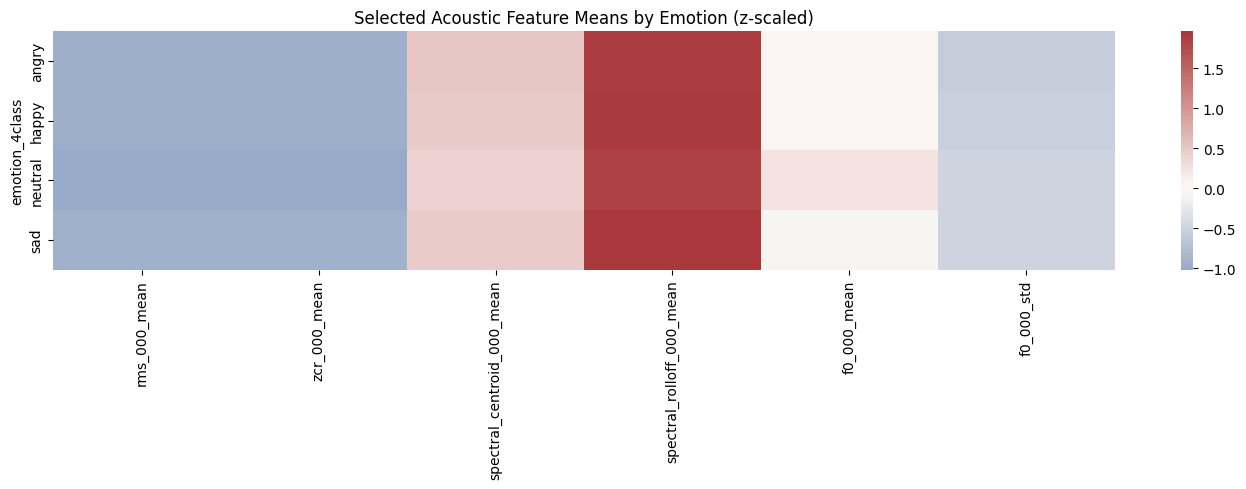

Saved: /kaggle/working/06_w2v_based_models/02_IEMOCAP Feature Extraction Emotion2Vec Acoustic/output/feature_figures/selected_feature_means_by_emotion_heatmap.png


In [13]:
if plt is not None:
    selected_cols = [c for c in stats_names if any(key in c for key in ["rms_000_mean", "f0_000_mean", "f0_000_std", "zcr_000_mean", "spectral_centroid_000_mean", "spectral_rolloff_000_mean"])]
    selected_cols = selected_cols[:30] if selected_cols else list(stats_names[:30])
    heat_df = stats_df.groupby("emotion_4class")[selected_cols].mean()
    heat_scaled = pd.DataFrame(
        StandardScaler().fit_transform(heat_df.T).T,
        index=heat_df.index,
        columns=heat_df.columns,
    )
    plt.figure(figsize=(14, 5))
    sns.heatmap(heat_scaled, cmap="vlag", center=0)
    plt.title("Selected Acoustic Feature Means by Emotion (z-scaled)")
    plt.tight_layout()
    fig_path = FIGURE_DIR / "selected_feature_means_by_emotion_heatmap.png"
    plt.savefig(fig_path, dpi=160)
    plt.show()
    print("Saved:", fig_path)


## Visualize One Sample Per Emotion

Mỗi emotion sẽ có:

- waveform
- log-Mel spectrogram
- MFCC
- F0 contour


,utterance_id,speaker_id,emotion_4class,transcript,duration
1703,Ses02F_script01_2_M001,Ses02M,neutral,"Well, maybe he just wanted to see her again.",3.129938
176,Ses01F_script02_2_F010,Ses01F,angry,Twice is every time we have tried; that's ever.,3.610500
3985,Ses04F_script01_3_M036,Ses04M,sad,And then I came home and it was amazing.,4.149875
3314,Ses04F_impro03_F051,Ses04F,happy,[LAUGHTER] That's more than I needed to know.,3.696875


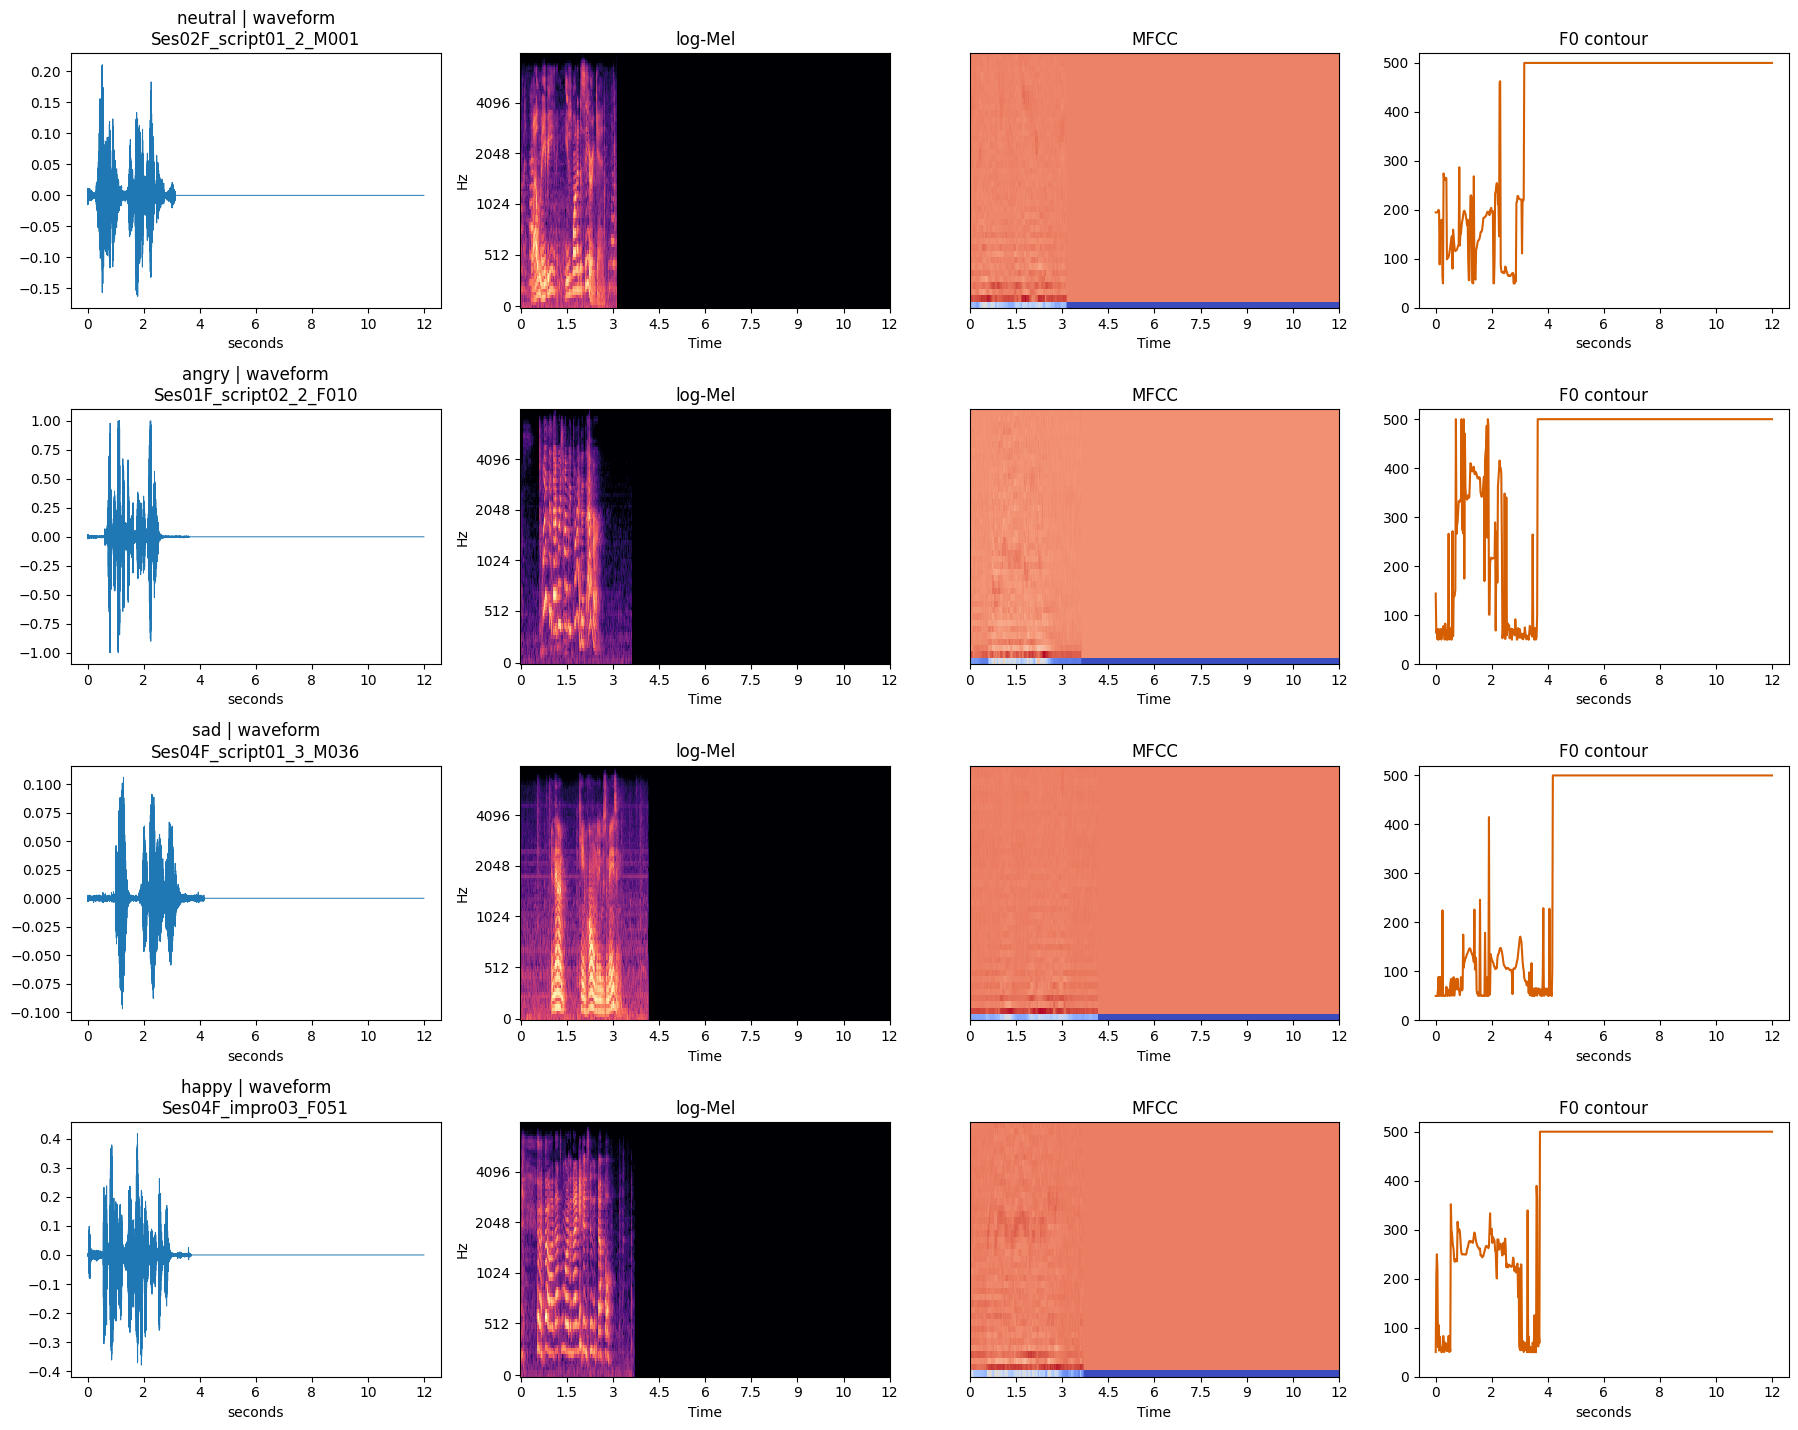

Saved: /kaggle/working/06_w2v_based_models/02_IEMOCAP Feature Extraction Emotion2Vec Acoustic/output/feature_figures/one_sample_per_emotion_feature_panels.png


In [14]:
def select_one_per_emotion(df):
    rows = []
    for emotion in ["neutral", "angry", "sad", "happy"]:
        part = df[df["emotion_4class"] == emotion].copy()
        if part.empty:
            continue
        if "duration" in part.columns:
            part["duration_distance"] = (part["duration"] - part["duration"].median()).abs()
            row = part.sort_values("duration_distance").iloc[0]
        else:
            row = part.iloc[0]
        rows.append(row)
    return pd.DataFrame(rows)

def plot_sample_features(selected_df, fig_name):
    if plt is None or selected_df.empty:
        return
    fig, axes = plt.subplots(len(selected_df), 4, figsize=(18, 3.6 * len(selected_df)))
    if len(selected_df) == 1:
        axes = np.expand_dims(axes, 0)
    for row_idx, (_, row) in enumerate(selected_df.iterrows()):
        wav_path = resolve_wav_path(row)
        y, _ = load_audio_16k_fixed(wav_path)
        feats = extract_acoustic_features(y)
        times = np.arange(len(y)) / SAMPLE_RATE

        axes[row_idx, 0].plot(times, y, linewidth=0.7)
        axes[row_idx, 0].set_title(f"{row['emotion_4class']} | waveform\n{row['utterance_id']}")
        axes[row_idx, 0].set_xlabel("seconds")

        librosa.display.specshow(feats["parts"]["logmel"], sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel", ax=axes[row_idx, 1])
        axes[row_idx, 1].set_title("log-Mel")

        librosa.display.specshow(feats["parts"]["mfcc"], sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis="time", ax=axes[row_idx, 2])
        axes[row_idx, 2].set_title("MFCC")

        f0 = feats["parts"]["f0"][0]
        frame_times = librosa.frames_to_time(np.arange(len(f0)), sr=SAMPLE_RATE, hop_length=HOP_LENGTH)
        axes[row_idx, 3].plot(frame_times, f0, color="#D55E00")
        axes[row_idx, 3].set_ylim(0, max(520, float(np.max(f0)) + 20))
        axes[row_idx, 3].set_title("F0 contour")
        axes[row_idx, 3].set_xlabel("seconds")

    plt.tight_layout()
    fig_path = FIGURE_DIR / fig_name
    plt.savefig(fig_path, dpi=160)
    plt.show()
    print("Saved:", fig_path)

selected_one = select_one_per_emotion(metadata)
selected_one.to_csv(REPORT_DIR / "selected_one_sample_per_emotion.csv", index=False, encoding="utf-8-sig")
display(selected_one[["utterance_id", "speaker_id", "emotion_4class", "transcript", "duration"]])
plot_sample_features(selected_one, "one_sample_per_emotion_feature_panels.png")


## Same Speaker, Different Emotions

IEMOCAP không đảm bảo cùng một câu được nói lại với nhiều emotion khác nhau. Vì vậy minh họa hợp lý hơn là:

1. Cố tìm một speaker có đủ nhiều emotion.
2. Lấy mỗi emotion một utterance từ speaker đó.
3. So sánh waveform/log-Mel/MFCC/F0.

Nếu có transcript trùng giữa nhiều emotion, notebook cũng lưu bảng candidate để kiểm tra.


,utterance_id,speaker_id,emotion_4class,transcript,duration
141,Ses01F_script01_3_F007,Ses01F,neutral,I knew they would.,2.884313
240,Ses01M_impro01_F008,Ses01F,angry,It's really simple if you have a problem with ...,3.736000
14,Ses01F_impro02_F010,Ses01F,sad,things just aren't what they seem.,4.250000
199,Ses01F_script03_1_F011,Ses01F,happy,Don't laugh at me. I'm being serious.,3.790000


Same transcript / different emotion candidates: 774


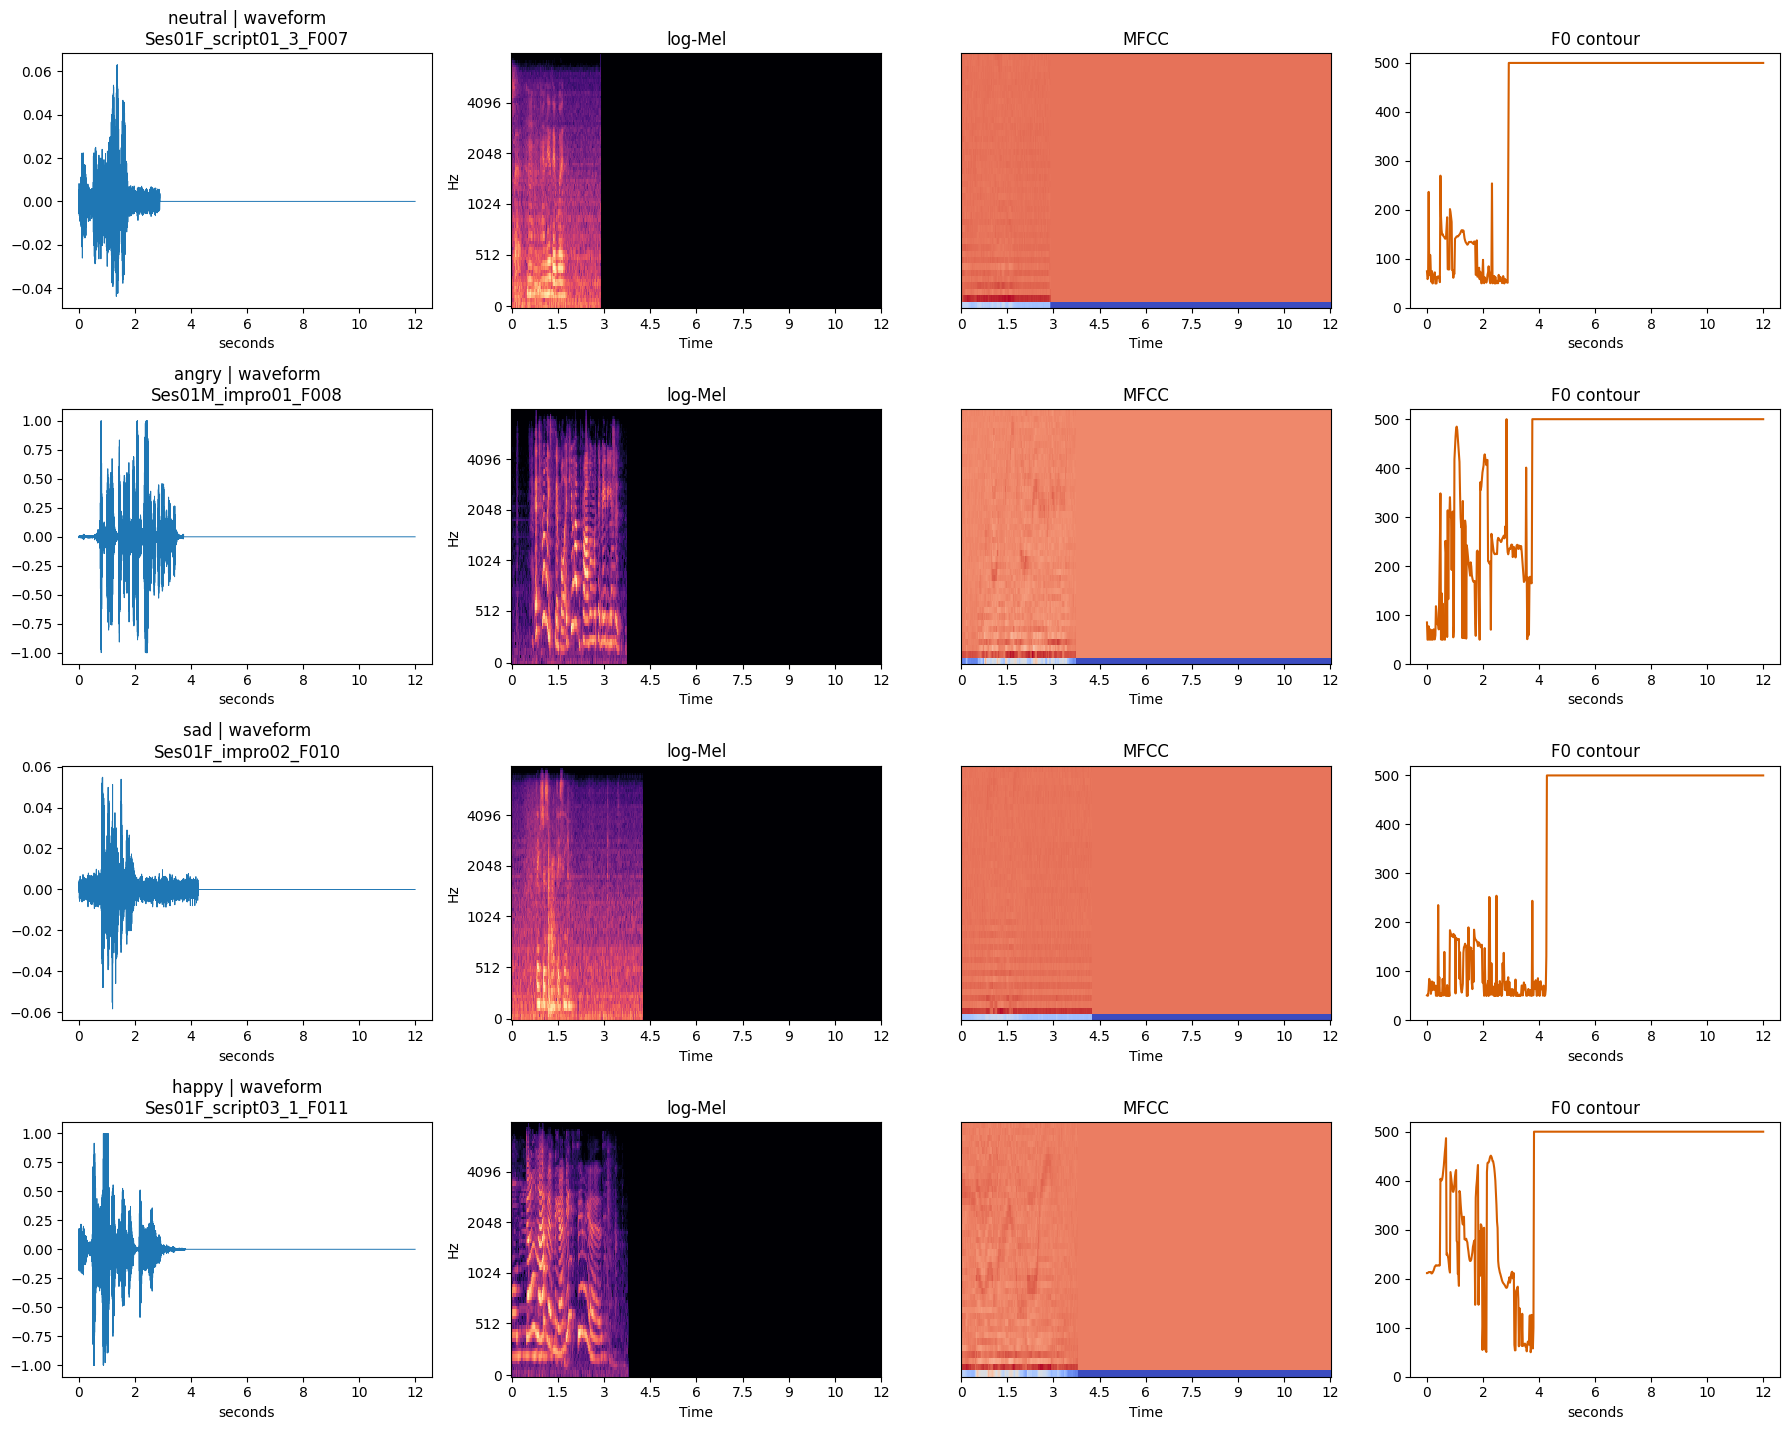

Saved: /kaggle/working/06_w2v_based_models/02_IEMOCAP Feature Extraction Emotion2Vec Acoustic/output/feature_figures/same_speaker_multi_emotion_feature_panels.png


In [15]:
def select_same_speaker_multi_emotion(df):
    counts = pd.crosstab(df["speaker_id"], df["emotion_4class"])
    counts["n_emotions"] = (counts.reindex(columns=["neutral", "angry", "sad", "happy"]).fillna(0) > 0).sum(axis=1)
    speaker = counts.sort_values(["n_emotions"], ascending=False).index[0]
    speaker_df = df[df["speaker_id"] == speaker]
    return select_one_per_emotion(speaker_df)

def normalized_transcript_for_match(text):
    text = normalize_text(text).lower()
    text = re.sub(r"[^a-z0-9 ]+", "", text)
    return re.sub(r"\s+", " ", text).strip()

metadata["transcript_norm_for_match"] = metadata.get("transcript", pd.Series([""] * len(metadata))).apply(normalized_transcript_for_match)
duplicate_transcript_candidates = (
    metadata[metadata["transcript_norm_for_match"].str.len() > 0]
    .groupby("transcript_norm_for_match")
    .filter(lambda x: x["emotion_4class"].nunique() > 1)
    .sort_values(["transcript_norm_for_match", "emotion_4class"])
)
duplicate_transcript_candidates.to_csv(REPORT_DIR / "same_transcript_different_emotion_candidates.csv", index=False, encoding="utf-8-sig")

same_speaker = select_same_speaker_multi_emotion(metadata)
same_speaker.to_csv(REPORT_DIR / "selected_same_speaker_multi_emotion.csv", index=False, encoding="utf-8-sig")
display(same_speaker[["utterance_id", "speaker_id", "emotion_4class", "transcript", "duration"]])
print("Same transcript / different emotion candidates:", len(duplicate_transcript_candidates))
plot_sample_features(same_speaker, "same_speaker_multi_emotion_feature_panels.png")


## PCA and Correlation Analysis


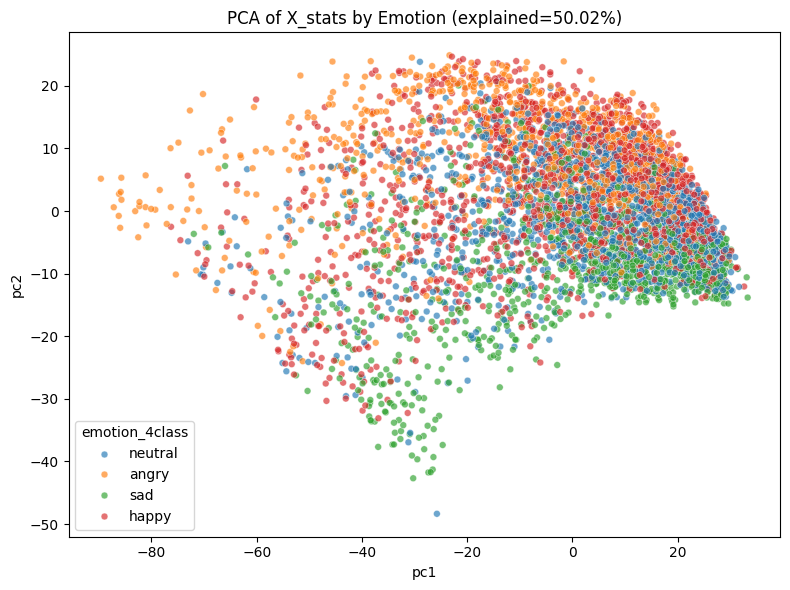

Saved: /kaggle/working/06_w2v_based_models/02_IEMOCAP Feature Extraction Emotion2Vec Acoustic/output/feature_figures/xstats_pca_by_emotion.png


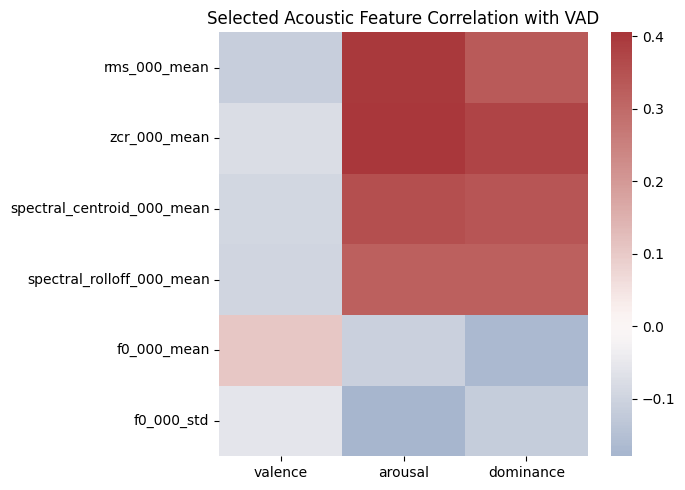

Saved: /kaggle/working/06_w2v_based_models/02_IEMOCAP Feature Extraction Emotion2Vec Acoustic/output/feature_figures/selected_feature_vad_correlation_heatmap.png


In [16]:
if plt is not None and len(metadata) >= 4:
    pca_input = StandardScaler().fit_transform(X_stats)
    pca = PCA(n_components=2, random_state=42)
    xy = pca.fit_transform(pca_input)
    pca_df = pd.DataFrame({
        "pc1": xy[:, 0],
        "pc2": xy[:, 1],
        "emotion_4class": metadata["emotion_4class"].to_numpy(),
        "speaker_id": metadata["speaker_id"].to_numpy(),
    })
    pca_df.to_csv(REPORT_DIR / "xstats_pca_projection.csv", index=False, encoding="utf-8-sig")

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=pca_df, x="pc1", y="pc2", hue="emotion_4class", alpha=0.65, s=24)
    plt.title(f"PCA of X_stats by Emotion (explained={pca.explained_variance_ratio_.sum():.2%})")
    plt.tight_layout()
    fig_path = FIGURE_DIR / "xstats_pca_by_emotion.png"
    plt.savefig(fig_path, dpi=160)
    plt.show()
    print("Saved:", fig_path)

    corr_cols = [c for c in stats_names if any(key in c for key in ["rms_000_mean", "f0_000_mean", "f0_000_std", "zcr_000_mean", "spectral_centroid_000_mean", "spectral_rolloff_000_mean"])]
    corr_cols = corr_cols[:20] if corr_cols else list(stats_names[:20])
    corr_df = stats_df[corr_cols + ["valence", "arousal", "dominance"]].corr().loc[corr_cols, ["valence", "arousal", "dominance"]]
    corr_df.to_csv(REPORT_DIR / "selected_feature_vad_correlations.csv", encoding="utf-8-sig")
    plt.figure(figsize=(7, max(5, len(corr_cols) * 0.28)))
    sns.heatmap(corr_df, annot=False, cmap="vlag", center=0)
    plt.title("Selected Acoustic Feature Correlation with VAD")
    plt.tight_layout()
    fig_path = FIGURE_DIR / "selected_feature_vad_correlation_heatmap.png"
    plt.savefig(fig_path, dpi=160)
    plt.show()
    print("Saved:", fig_path)


## Final Report


In [17]:
truncation_rate = float(pd.DataFrame(preprocess_rows)["was_truncated"].mean()) if preprocess_rows else 0.0
duration_desc = metadata["duration"].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95]).round(3)
emotion_counts = metadata["emotion_4class"].value_counts().to_dict()

report_lines = [
    "# IEMOCAP Feature Extraction Report",
    "",
    "## Scope",
    "",
    f"- Samples: **{len(metadata):,}**.",
    f"- Feature cache: `{cache_path}`.",
    f"- Sample rate: **{SAMPLE_RATE} Hz**.",
    f"- Max seconds: **{MAX_SECONDS}**.",
    f"- Target frames: **{TARGET_FRAMES}**.",
    f"- Truncation rate after fixed-length preprocessing: **{truncation_rate * 100:.2f}%**.",
    "",
    "## Shapes",
    "",
    f"- `X_temporal`: `{X_temporal.shape}`.",
    f"- `X_spectral`: `{X_spectral.shape}`.",
    f"- `X_stats`: `{X_stats.shape}`.",
    f"- `X_e2v`: `{X_e2v.shape}`.",
    f"- `X_text_stats`: `{X_text_stats.shape}`.",
    "",
    "## Class Counts",
    "",
]
for emotion, count in sorted(emotion_counts.items()):
    report_lines.append(f"- {emotion}: **{count:,}**")

report_lines += [
    "",
    "## Duration",
    "",
    f"- Mean: **{duration_desc['mean']:.3f}s**.",
    f"- Median: **{duration_desc['50%']:.3f}s**.",
    f"- 95th percentile: **{duration_desc['95%']:.3f}s**.",
    f"- Max: **{duration_desc['max']:.3f}s**.",
    "",
    "## Downstream Usage",
    "",
    "- 03A raw pretrained backbone: use metadata/splits and raw audio.",
    "- 03B acoustic co-attention: use `iemocap_full_06d_multibranch_cache.npz`.",
    "- Transcript branch: use `text/text_ready_metadata.csv` and `text/text_folds_long.csv`.",
    "- 04 fusion: align by `train_sample_id` and `utterance_id`.",
    "",
    "## Important Note",
    "",
    "No augmentation is applied in notebook 02. Any augmentation should be train-only inside model notebooks.",
]

report_path = REPORT_DIR / "feature_extraction_report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")
display(Markdown(report_path.read_text(encoding="utf-8")))
print("Saved report:", report_path)


# IEMOCAP Feature Extraction Report

## Scope

- Samples: **5,531**.
- Feature cache: `/kaggle/working/06_w2v_based_models/02_IEMOCAP Feature Extraction Emotion2Vec Acoustic/output/features/iemocap_full_06d_multibranch_cache.npz`.
- Sample rate: **16000 Hz**.
- Max seconds: **12.0**.
- Target frames: **601**.
- Truncation rate after fixed-length preprocessing: **3.78%**.

## Shapes

- `X_temporal`: `(5531, 135, 601)`.
- `X_spectral`: `(5531, 3, 96, 601)`.
- `X_stats`: `(5531, 1224)`.
- `X_e2v`: `(5531, 768)`.
- `X_text_stats`: `(5531, 6)`.

## Class Counts

- angry: **1,103**
- happy: **1,636**
- neutral: **1,708**
- sad: **1,084**

## Duration

- Mean: **4.549s**.
- Median: **3.576s**.
- 95th percentile: **11.059s**.
- Max: **34.139s**.

## Downstream Usage

- 03A raw pretrained backbone: use metadata/splits and raw audio.
- 03B acoustic co-attention: use `iemocap_full_06d_multibranch_cache.npz`.
- Transcript branch: use `text/text_ready_metadata.csv` and `text/text_folds_long.csv`.
- 04 fusion: align by `train_sample_id` and `utterance_id`.

## Important Note

No augmentation is applied in notebook 02. Any augmentation should be train-only inside model notebooks.

Saved report: /kaggle/working/06_w2v_based_models/02_IEMOCAP Feature Extraction Emotion2Vec Acoustic/output/feature_reports/feature_extraction_report.md


In [18]:
manifest_rows = []
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        relative_path = path.relative_to(OUTPUT_DIR)
        manifest_rows.append({
            "relative_path": str(relative_path).replace("\\", "/"),
            "folder": relative_path.parts[0] if relative_path.parts else "",
            "bytes": int(path.stat().st_size),
        })

manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(REPORT_DIR / "output_manifest.csv", index=False, encoding="utf-8-sig")
display(manifest_df)

zip_path = OUTPUT_DIR.with_suffix(".zip")
if zip_path.exists():
    zip_path.unlink()
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in OUTPUT_DIR.rglob("*"):
        if path.is_file():
            zf.write(path, path.relative_to(OUTPUT_DIR.parent))
print("Saved zip:", zip_path)


,relative_path,folder,bytes
0,feature_figures/one_sample_per_emotion_feature...,feature_figures,567753
1,feature_figures/same_speaker_multi_emotion_fea...,feature_figures,568336
2,feature_figures/selected_feature_means_by_emot...,feature_figures,66044
3,feature_figures/selected_feature_vad_correlati...,feature_figures,51706
4,feature_figures/xstats_pca_by_emotion.png,feature_figures,600219
5,feature_reports/audio_preprocessing_summary.csv,feature_reports,1212991
6,feature_reports/audio_resolve_smoke_test.csv,feature_reports,3290
7,feature_reports/duration_by_emotion.csv,feature_reports,326
8,feature_reports/feature_cache_summary.csv,feature_reports,391
9,feature_reports/feature_extraction_report.md,feature_reports,1183


Saved zip: /kaggle/working/06_w2v_based_models/02_IEMOCAP Feature Extraction Emotion2Vec Acoustic/output.zip
